# Time Series Comparison

# Import Packages
Add your packages here

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path


from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines

import warnings
warnings.filterwarnings("ignore")

# Utility Functions
include any helper or utlity functions below

In [3]:
## function to generate time series with normalized points
def to_ts(data, dates=None):
    data = data.copy()
    aDict = {'ts': np.array(data)}
    aRange = np.arange(len(data))
    aDict['pts'] = (aRange - np.min(aRange)) / np.max(aRange)
    if dates is not None:
        indexDates = pd.to_datetime(dates, errors='coerce')
    elif isinstance(data, pd.Series) and isinstance(data.index, pd.DatetimeIndex):
        indexDates = data.index
    else:
        indexDates = aRange
    return pd.DataFrame(aDict, index=indexDates).dropna()

## Function for performance metrics 
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true+1e-6 - pred) ** 2) / np.sum((true+1e-6 - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)

## Functions for plotting time series and residuals
def ts_plot(x, y, title: str, xlabel: str, ylabel: str, figsize=(12, 4)):
    fig = plt.figure(figsize=figsize)
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

    return fig

def residual_plot(residual, lags: int, title: str, xlabel: str = "Date", ylabel:str = "Residual"):
    plt.figure(figsize=(12,4))
    plt.plot(residual)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    plot_acf(residual, lags=lags, ax=axs[0])
    axs[0].set_title("ACF of Residual")

    plot_pacf(residual, lags=lags, ax=axs[1], method="ywm")
    axs[1].set_title("PACF of Residual")

    plt.tight_layout()
    plt.show()

# Dataset 1: Bogus Basin Snow

## Plot and Exploratory Analysis

*Reading in  data*

In [4]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])

snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_daily = to_ts(snow_data['Depth'], snow_data.index)


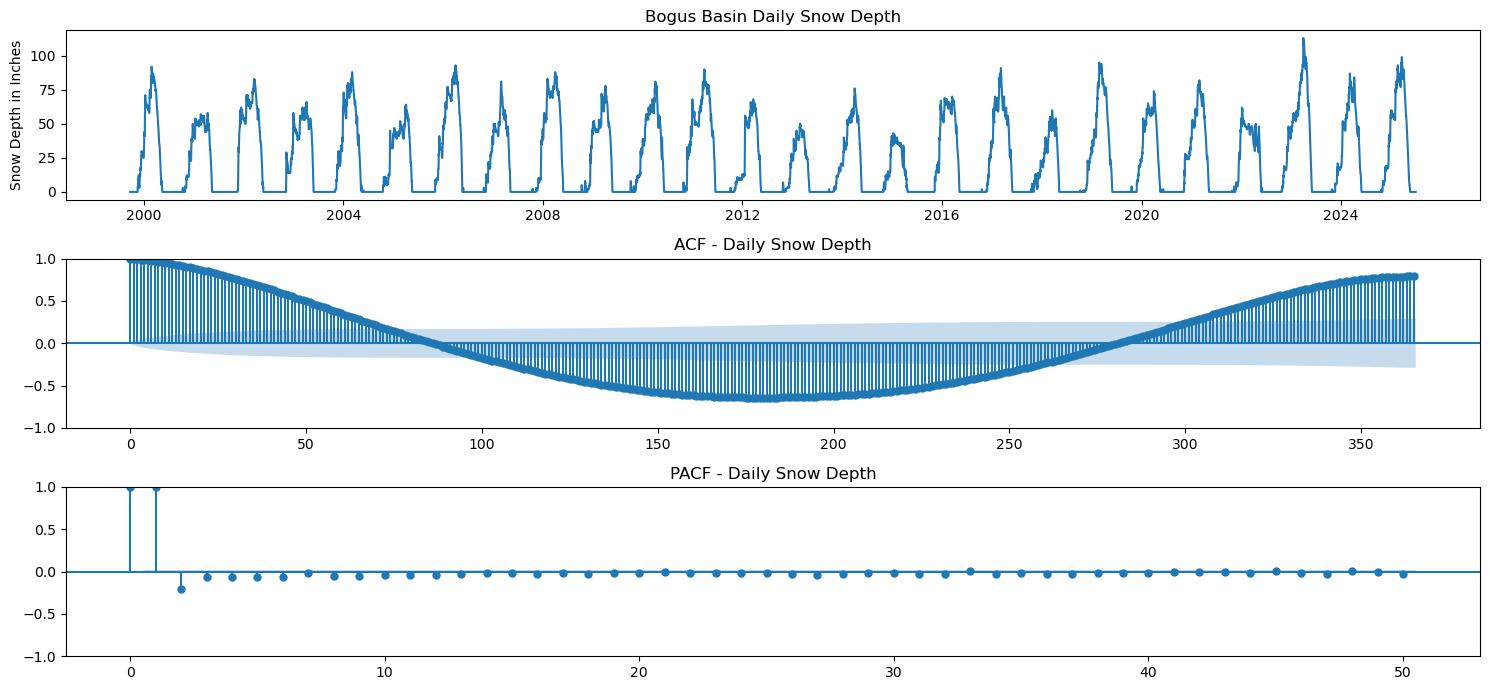

In [5]:
fig, axs = plt.subplots(3,1 ,figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")
plot_acf(snow_daily['ts'], lags = 365, ax = axs[1], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[2], title = "PACF - Daily Snow Depth");

fig.tight_layout()
fig.show()

The daily snow data exhibits a strong seasonal pattern with no clear discernable trend. A key feature of this data is the large periods of time with zero values during the warmer months.  While one approach could be to remove all the zero values, they are a key data point, as forecasting when snow begins and ends is a key part of this analysis.  Close attention will be paid to how successful the models are in capturing these zero points. 

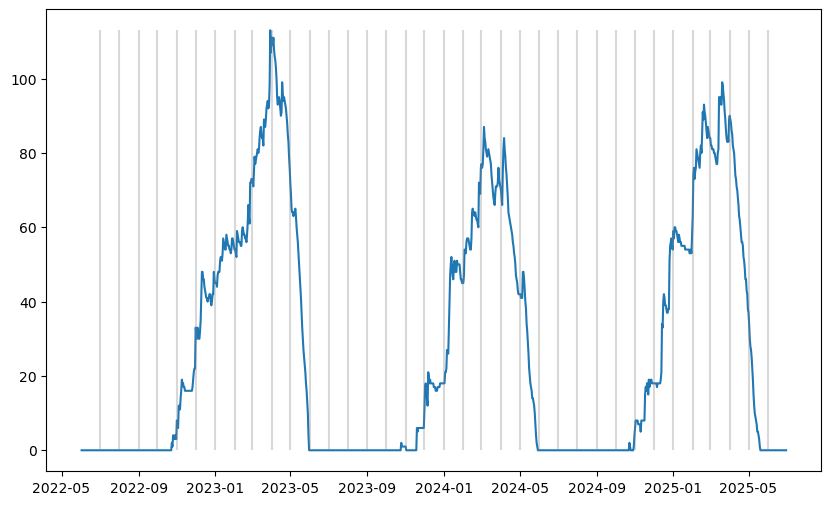

In [ ]:
last_3_years = snow_daily[snow_daily.index > '2022-06-01']
loc = mdates.MonthLocator(bymonthday=1)
month_starts = loc.tick_values(last_3_years.index.min(), last_3_years.index.max())

plt.figure(figsize=(10,6))
plt.plot(last_3_years['ts'])
plt.vlines(month_starts, 0,last_3_years['ts'].max(), alpha = .3, color = 'grey')

say something about the pattern in each year

## Modeling



Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical viariables at month, week, and day levels for seasonal analysis 

In [ ]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())


            ts       pts  month  week  day
Date                                      
2024-05-27   4  0.957598      5    22  148
2024-05-28   2  0.957705      5    22  149
2024-05-29   1  0.957811      5    22  150
2024-05-30   0  0.957917      5    22  151
2024-05-31   0  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   0  0.958130      6    22  153
2024-06-02   0  0.958236      6    22  154
2024-06-03   0  0.958342      6    23  155
2024-06-04   0  0.958448      6    23  156
2024-06-05   0  0.958555      6    23  157


# Dataset 2: 

# Dataset 3: 


# Dataset 4:

# Dataset 5: